In [1]:
"""
movement_fitter.ipynb
========================
Investigates the fitting of ratiometric movement events in mass photometry.
"""
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator

from alex_area import utils, plotting
from alex_area.movie_generator.buffer_movies import BufferMovie, load_buffer_movies
from alex_area.movie_generator.sim_movie import BufferMovieSim, RustPSF
from alex_area.pairmatching_benchmark.mass_pos_err_bench import rand_l_thum_stack
from tandemmp.utils.conversions import conversion_funcs
import scipy.optimize
from dataclasses import dataclass, field
from typing import Optional

## Configuration

In [2]:
# --- File paths ---
PSF_PATH = (
    r"C:\Users\chem-bras5436\Documents\MP_DATA\citrate_synthase\TwoMP"
    r"\buffer_movies\unbinned\011_20241115_s_elo_wt_his_tag_7500x_expPSF.pickle"
)

# --- Geometry ---
L_THUM = 21        # Thumbnail side length (pixels)
N_SAMPLE = 21      # Grid sample density for noise-free PSF evaluation
STACK_LENGTH = 11  # Frames per simulated buffer-movie stack

# --- Acquisition ---
NM_PER_PIXEL = 72.6  # Spatial calibration (nm px⁻\xb9)
FPS = 106.14 / 3     # Neutral-pH frame rate (Hz); 106.14 Hz camera / 3 averaged frames

# Convenience: plot extent in pixel-unit coordinates
EXTENT = [-L_THUM / 2, L_THUM / 2, -L_THUM / 2, L_THUM / 2]

# --- Buffer movie ---
B_MOVS: list[BufferMovie] = load_buffer_movies()
B_MOV = B_MOVS[0]

## 1. Load Experimental PSF

In [3]:
_raw_psf = utils.load_from_pickle(PSF_PATH)

def expPSF(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Evaluate the experimental PSF at arbitrary (x, y) coordinates.

    Thin wrapper around the raw RectBivariateSpline interpolator that fixes
    ``grid=False`` so callers can pass flat coordinate arrays directly.

    Parameters
    ----------
    x, y :
        Coordinate arrays in pixel units, as returned by
        ``CachedPSF._gen_offset_mgrid``.

    Returns
    -------
    np.ndarray
        PSF amplitude at each coordinate pair.
    """
    return _raw_psf(x, y, grid=False)

rustPSF = RustPSF(l_thum=L_THUM)

## 2. Helper Functions

In [4]:
def movement_event_generator(
    start_pos: tuple[float, float],
    end_pos: tuple[float, float],
    start_frame: float,
    end_frame: float,
    contrast: float,
) -> list[list[float]]:
    """Build the two-event list describing a single particle movement.

    A movement is encoded as an *unbinding* event at ``start_pos`` followed
    by a *binding* event at ``end_pos``.  Contrast signs follow the TandemMP
    convention: departure is negative, arrival is positive.

    Parameters
    ----------
    start_pos :
        (x, y) pixel coordinates of the departure site.
    end_pos :
        (x, y) pixel coordinates of the arrival site.
    start_frame :
        Frame index at which the particle departs.
    end_frame :
        Frame index at which the particle arrives.
    contrast :
        Absolute contrast value (positive float); sign is applied internally.

    Returns
    -------
    list[list[float]]
        ``[[x, y, frame, contrast], ...]`` with two entries — unbinding then
        binding — as expected by ``BufferMovieSim.work``.
    """
    unbinding_ev = [start_pos[0], start_pos[1], start_frame, -contrast]
    binding_ev   = [end_pos[0],   end_pos[1],   end_frame,    contrast]
    return [unbinding_ev, binding_ev]


def r_theta_2_dx_dy(distance: float, angle_degrees: float) -> np.ndarray:
    """Convert polar displacement to Cartesian (dx, dy).

    Parameters
    ----------
    distance :
        Displacement magnitude in the caller's chosen units (typically nm).
    angle_degrees :
        Angle measured counter-clockwise from the positive x-axis, in degrees.

    Returns
    -------
    np.ndarray
        Shape ``(2,)`` array ``[dx, dy]`` in the same units as *distance*.
    """
    angle = np.radians(angle_degrees)
    return np.array([distance * np.cos(angle), distance * np.sin(angle)])


def simulate_ratiometric_frame(
    mass: float,
    distance: float,
    angle_degrees: float,
    background_stack: np.ndarray,
    simulator: BufferMovieSim,
    *,
    x_off: float = 0.0,
    y_off: float = 0.0,
    time_taken: float = 0.0,
) -> np.ndarray:
    """Simulate a ratiometric frame for a single moving particle on a buffer background.

    Embeds a two-event movement (departure + arrival) into the temporal midpoint
    of *background_stack* and returns ``post / pre - 1``, where *pre* and *post*
    are the per-pixel temporal means before and after the event frame.

    Parameters
    ----------
    mass :
        Particle mass in kDa.
    distance :
        Distance moved in nm.
    angle_degrees :
        Direction of movement, counter-clockwise from the positive x-axis (degrees).
    background_stack :
        Raw buffer-movie patch, shape ``(STACK_LENGTH, L_THUM, L_THUM)``.
        This array is not modified in place.
    simulator :
        Initialised ``BufferMovieSim`` instance.
    x_off, y_off :
        Sub-pixel offset of the particle from the thumbnail centre, in pixels.
    time_taken :
        Number of frames elapsed between departure and arrival.  Zero means the
        particle jumps instantaneously (both events share the same frame index).

    Returns
    -------
    np.ndarray
        Ratiometric frame ``post / pre - 1``, shape ``(L_THUM, L_THUM)``.
    """
    n_frames  = background_stack.shape[0]
    l_px      = background_stack.shape[1]
    centre    = l_px // 2      # array-index centre (e.g. 10 for L_THUM=21)
    midframe  = n_frames // 2  # event frame index  (e.g.  5 for STACK_LENGTH=11)
    contrast  = conversion_funcs["mass_to_c"](mass)

    x_moved, y_moved = r_theta_2_dx_dy(distance, angle_degrees) / NM_PER_PIXEL

    events = movement_event_generator(
        start_pos=(centre + x_off, centre + y_off),
        end_pos=(centre + x_off + x_moved, centre + y_off + y_moved),
        start_frame=midframe,
        end_frame=midframe + time_taken,
        contrast=contrast,
    )

    sim  = simulator.work(movie=background_stack.copy(), events=events).astype(np.int32)
    pre  = sim[:midframe].mean(axis=0)
    post = sim[midframe:].mean(axis=0)
    return -(post / pre - 1)


def configure_pixel_axes(ax: plt.Axes, major: int = 5, minor: int = 1) -> None:
    """Set major and minor tick intervals (in pixels) on both axes of *ax*.

    Parameters
    ----------
    ax :
        Axes to configure.
    major, minor :
        Tick spacing in pixels.
    """
    ax.xaxis.set_major_locator(MultipleLocator(major))
    ax.yaxis.set_major_locator(MultipleLocator(major))
    ax.xaxis.set_minor_locator(MultipleLocator(minor))
    ax.yaxis.set_minor_locator(MultipleLocator(minor))


def plot_ratiometric_frame(
    frame: np.ndarray,
    title: str,
    *,
    vmin: float = -0.01,
    vmax: float = 0.01,
) -> None:
    """Display a ratiometric frame as a greyscale image with a contrast colour bar.

    Parameters
    ----------
    frame :
        2-D ratiometric array ``post / pre - 1``, shape ``(L_THUM, L_THUM)``.
    title :
        Axes title string.
    vmin, vmax :
        Colour-scale limits.  Defaults bracket ±1 % contrast.
    """
    fig, ax = plt.subplots(1, 1, dpi=300, figsize=plotting.DEFAULT_FIG_SIZE)
    ax.imshow(frame, cmap="gray", extent=EXTENT, vmin=vmin, vmax=vmax)
    ax.set_title(title)
    configure_pixel_axes(ax)
    plt.colorbar(ax.images[0], ax=ax, label="Contrast")
    plt.tight_layout()
    plt.show()

## 3. Simulator

Instantiate a ``BufferMovieSim`` using the Rust PSF model.  This instance
is shared by all subsequent simulation sections.

In [5]:
simulator = BufferMovieSim(psf_model=rustPSF)

## 4. Flat Background Simulation

Generate a spatially-uniform background (every pixel = 32 767 ADU) and apply
Poisson noise.  This isolates the effect of photon shot-noise without any
spatial structure from the buffer movie.

The buffer-movie calibration is applied once here and shared by §5 and §6.

In [6]:
FLAT_VALUE = 32_767  # uniform background level (2¹⁵ − 1 ADU)

rng = np.random.default_rng(seed=42)

# Apply buffer-movie calibration once; reused by §5 and §6
calibration = B_MOV.calibration
conversion_funcs["c_to_mass"] = lambda c: (c - calibration["intercept"]) / calibration["c2kDa"]
conversion_funcs["mass_to_c"] = lambda m: m * calibration["c2kDa"] + calibration["intercept"]

# Generate Poisson-noise flat stack at thumbnail size.
# Every spatial patch is statistically equivalent, so rand_l_thum_stack is unnecessary.
flat_lam   = FLAT_VALUE * 360  # photon-space lambda (×360 gain factor)
flat_stack = (
    rng.poisson(flat_lam, size=(STACK_LENGTH, L_THUM, L_THUM)) / 360.0
).astype(np.uint16)

### 4.1 Ratiometric Movements on a Flat Background

##### Showing that small movements are a signal detection problem

In [ ]:
results = np.zeros((51,51), dtype=float)
midframe = flat_stack.shape[0] // 2
flat_r_blank = -(flat_stack[midframe:].mean(axis=0) / flat_stack[:midframe].mean(axis=0) - 1)

for i, dist in enumerate(np.linspace(0, 10, 51)):
    for j, mass in enumerate(np.linspace(3_000, 6_000, 51)):
        r_3000_flat = simulate_ratiometric_frame(
        mass=mass,
        distance=dist,
        angle_degrees=0.0,
        background_stack=flat_stack,
        simulator=simulator,
        x_off=0.0,
        y_off=0.0,
    )
        diff = r_3000_flat - flat_r_blank

        max_signal_change = np.max(np.abs(diff))

        results[i,j] = max_signal_change

        print(f"({mass} kDa, {dist} nm) done")

Adding events: 100%|██████████| 2/2 [00:00<00:00, 1999.67events/s]


(3000.0 kDa, 0.0 nm) done


Adding events: 100%|██████████| 2/2 [00:00<00:00, 2006.36events/s]


(3060.0 kDa, 0.0 nm) done


Adding events: 100%|██████████| 2/2 [00:00<00:00, 2000.14events/s]

...

(5880.0 kDa, 10.0 nm) done


Adding events: 100%|██████████| 2/2 [00:00<00:00, 2004.45events/s]


(5940.0 kDa, 10.0 nm) done


Adding events: 100%|██████████| 2/2 [00:00<?, ?events/s]

(6000.0 kDa, 10.0 nm) done


In [8]:
from matplotlib import colormaps
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from typing import Literal


def get_nature_colours(
    tint: int = 3, palette_name: Literal["extended", "main"] = "extended"
) -> ListedColormap:

    nature_extended = {
        "Olive": ["#DFDC67", "#C9C700", "#9BA415", "#66771E", "#36461A"],
        "Green": ["#A0CA79", "#62B347", "#459434", "#227130", "#163B1C"],
        "Teal": ["#97D2D4", "#4BBCBD", "#019AA3", "#016879", "#00394E"],
        "Blue": ["#9DCBEC", "#5799D1", "#0272B2", "#014E91", "#012C5C"],
        "Purple": ["#D3AAD1", "#BB7CB4", "#A84E94", "#792C74", "#481951"],
        "Red": ["#EDA4A7", "#DE6866", "#C93E3F", "#9C2826", "#741915"],
        "Orange": ["#FBC07F", "#F59A45", "#EC6F00", "#B74F06", "#843200"],
        "Yellow": ["#F6DC8A", "#EBC850", "#CCA02C", "#9C7717", "#6B5513"],
        "Skin tones": ["#DDBDA3", "#BF997D", "#936A57", "#755040", "#442D1F"],
    }

    nature_main = {
        "Red": ["#FAD0CE", "#EDA4A7", "#DE6866", "#C93E3F", "#9C2826"],
        "Blue": ["#C8E7FB", "#9DCBEC", "#5799D1", "#0272B2", "#014E91"],
        "Glow": ["#FFF1C3", "#F6DC8A", "#EBC850", "#CCA02C", "#9C7717"],
        "Tone": ["#F7F5EF", "#E4E0CE", "#C6C2A6", "#A7A285", "#888366"],
        "Grey": ["#E6E6ED", "#C8CEDA", "#9BA3B4", "#6E7A90", "#49566D"],
    }

    palettes = {
        "extended": nature_extended,
        "main": nature_main,
    }

    if not 0 <= tint <= 4:
        raise ValueError(f"tint must be 0-4, got {tint}")

    palette = palettes[palette_name]

    colours = [cs[tint] for cs in palette.values()]

    return ListedColormap(colours, name=f"nature_{palette_name}_tint{tint}")


extended_tint4 = get_nature_colours(tint=3).colors
extended_tint3 = get_nature_colours(tint=2).colors
main_tint4 = get_nature_colours(tint=3, palette_name="main").colors
main_tint3 = get_nature_colours(tint=2, palette_name="main").colors
main_tint2 = get_nature_colours(tint=1, palette_name="main").colors
main_tint1 = get_nature_colours(tint=0, palette_name="main").colors

(<Axes: xlabel='Mass (kDa)', ylabel='Distance moved (nm)'>,
 <matplotlib.colorbar.Colorbar at 0x21d54678e60>)

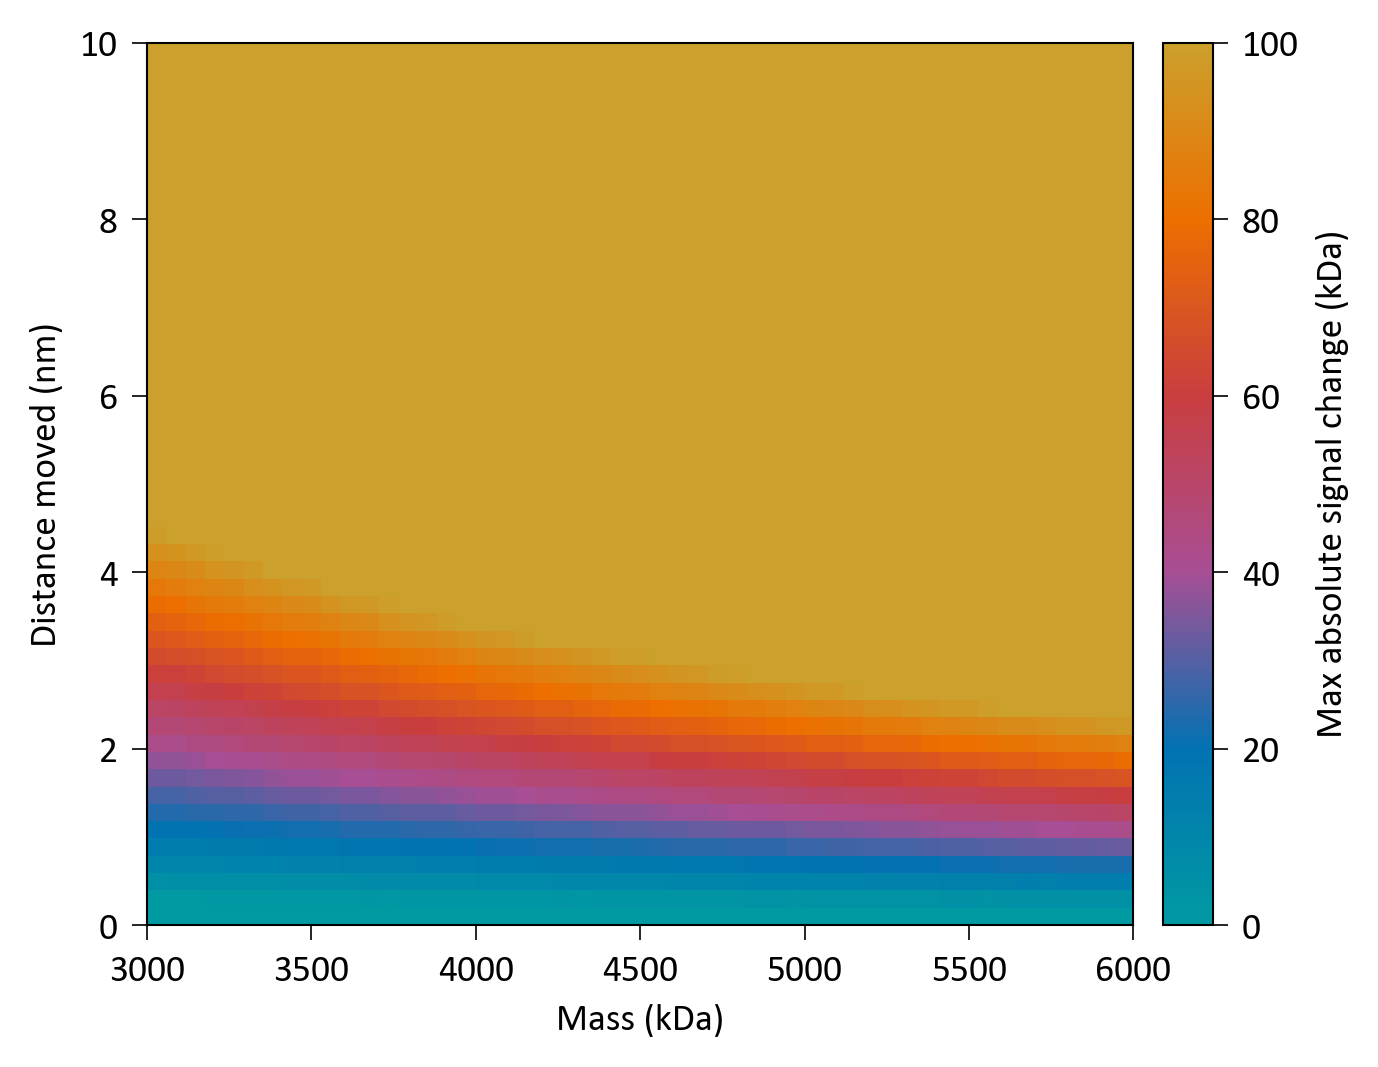

In [9]:
_pt_cmap = ListedColormap(
    extended_tint3[2:8], name="pt_segment_colours"
)
colormaps.register(_pt_cmap, force=True)
_PT_CMAP = _pt_cmap.name

_cmap_cont = LinearSegmentedColormap.from_list("pt_continuous", list(_pt_cmap.colors))

fig, ax = plt.subplots(1, 1, dpi=300, figsize=(1.2*3.8206713545000004,3.8206713545000004))

im = ax.imshow(-conversion_funcs['c_to_mass'](results), origin='lower', extent=(3000.0, 6000.0, 0.0, 10.0), aspect='auto', cmap=_cmap_cont, vmin=0, vmax=100)
ax.set_xlabel('Mass (kDa)')
ax.set_ylabel('Distance moved (nm)')
plotting.add_colourbar(ax=ax, mappable=im, label='Max absolute signal change (kDa)')

##### Sims on a flat background

Adding events: 100%|██████████| 2/2 [00:00<00:00, 1997.76events/s]


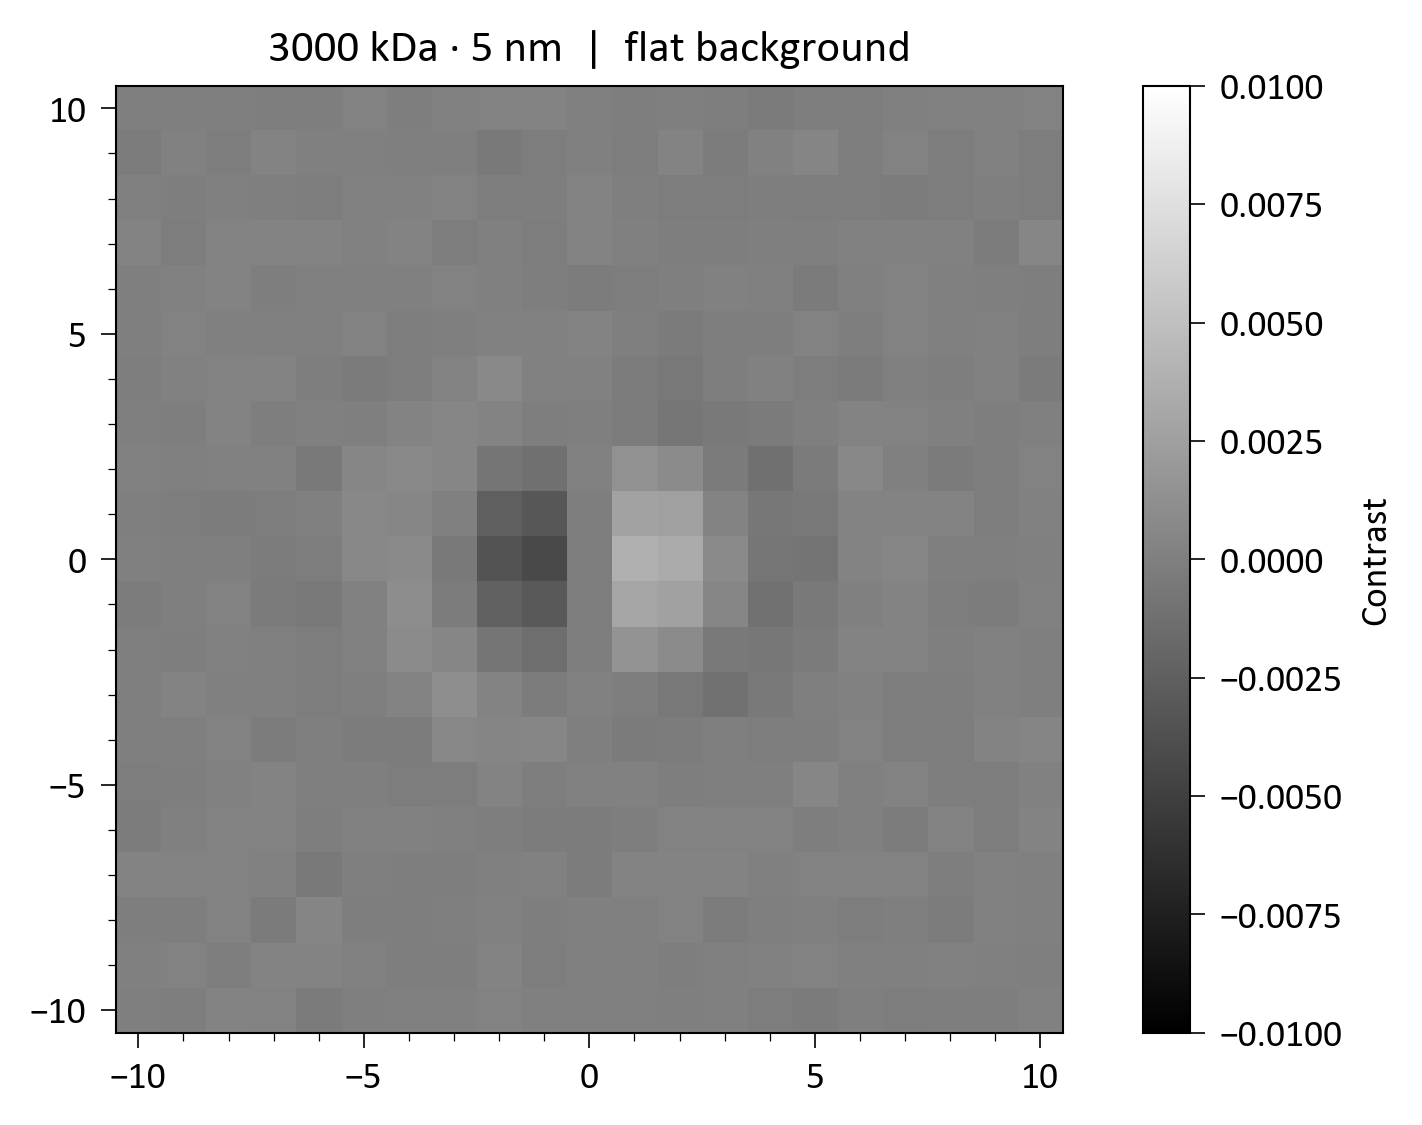

In [10]:
FLAT_DISTANCE_NM = 5
X_OFFSET_PX = 0.0
Y_OFFSET_PX = 0.0

r_3000_flat = simulate_ratiometric_frame(
    mass=3_000,
    distance=FLAT_DISTANCE_NM,
    angle_degrees=0.0,
    background_stack=flat_stack,
    simulator=simulator,
    x_off=X_OFFSET_PX,
    y_off=Y_OFFSET_PX,
)

plot_ratiometric_frame(r_3000_flat, f"3000 kDa · {FLAT_DISTANCE_NM} nm  |  flat background")

## 5. Idealised Background Simulation

Generate an idealised movie with Poisson noise only, using the first frame
of the buffer movie as the spatially-varying lambda map.  This adds realistic
spatial intensity variation while eliminating true camera noise.

In [11]:
rng = np.random.default_rng(seed=8)  # fresh seed for reproducible idealised noise
b_mov = B_MOV

length, height, width = b_mov.shape
lam_scaled = np.clip(b_mov[0].astype(int), 0, None) * 360  # non-negative photon-space lambda

# Generate idealised Poisson-noise-only movie (spatial structure from buffer frame 0)
ideal_noisy_mov = (
    rng.poisson(lam_scaled, size=(length, height, width)) / 360.0
).astype(np.uint16)

### 5.1 Ratiometric Movements on an Idealised Background

Both scenarios are simulated on the same randomly-sampled patch of
``ideal_noisy_mov`` so that Poisson noise contributes identically to both frames.

Adding events: 100%|██████████| 2/2 [00:00<?, ?events/s]


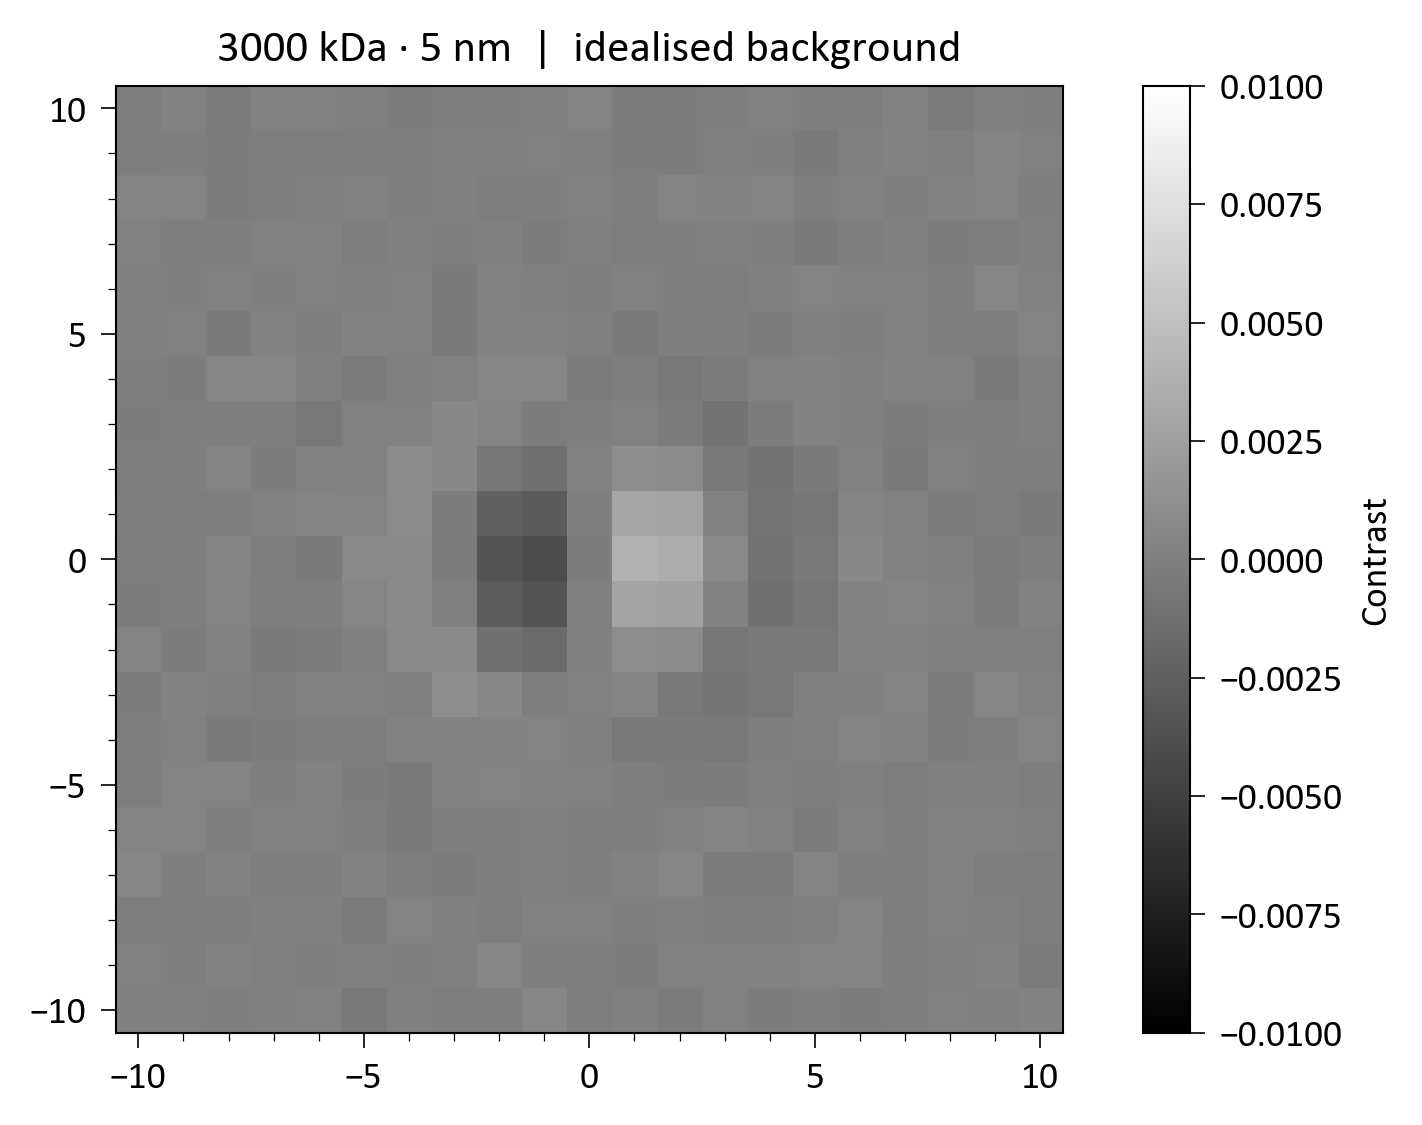

In [12]:
rand_stack = rand_l_thum_stack(arr=ideal_noisy_mov, l_thum=L_THUM, length=STACK_LENGTH)

IDEAL_DISTANCE_NM = 5
X_OFFSET_PX = 0.0
Y_OFFSET_PX = 0.0

r_3000_ideal = simulate_ratiometric_frame(
    mass=3_000,
    distance=IDEAL_DISTANCE_NM,
    angle_degrees=0.0,
    background_stack=rand_stack,
    simulator=simulator,
    x_off=X_OFFSET_PX,
    y_off=Y_OFFSET_PX,
)

plot_ratiometric_frame(r_3000_ideal, f"3000 kDa · {IDEAL_DISTANCE_NM} nm  |  idealised background")

## 6. Buffer Movie Background

Simulate on a patch drawn directly from the real buffer movie.  This is the
most realistic scenario, combining both spatial background structure and the
true noise distribution of the experimental data.

In [13]:
b_mov = B_MOV  # calibration applied in §4

### 6.1 Ratiometric Movements on a Buffer Background

Both scenarios are simulated on the **same** randomly-sampled buffer
region so that photon and read-out noise contribute identically to both frames.

Adding events: 100%|██████████| 2/2 [00:00<00:00, 2002.05events/s]


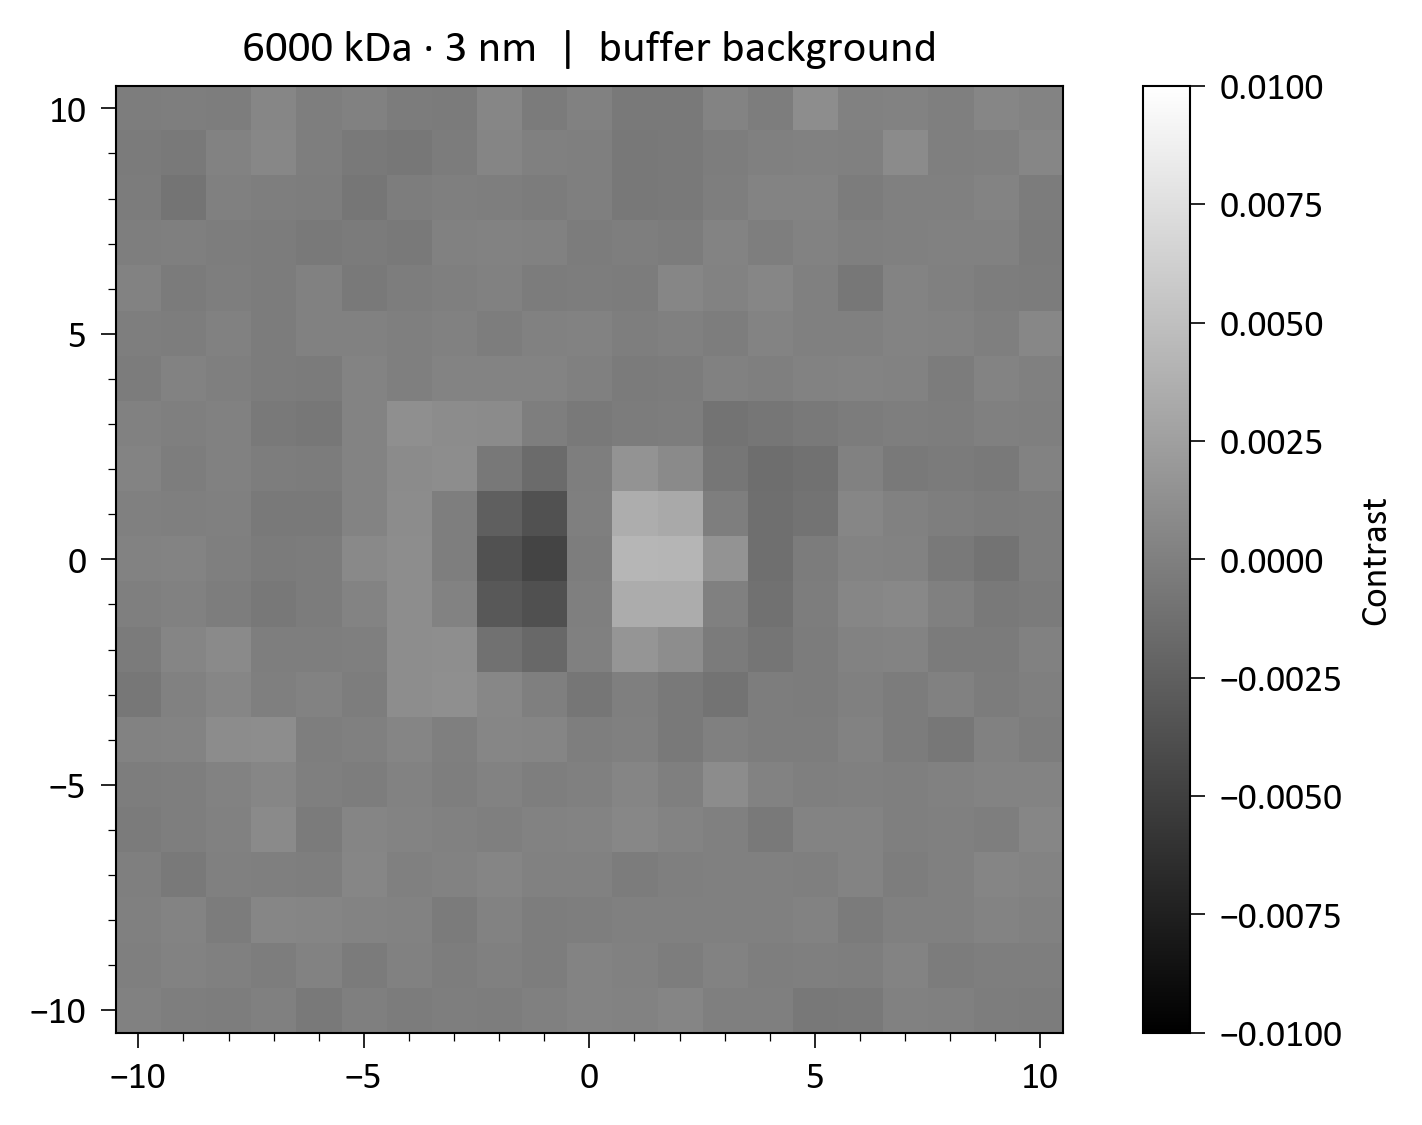

In [14]:
rand_stack = rand_l_thum_stack(arr=b_mov, l_thum=L_THUM, length=STACK_LENGTH)

BUFFER_DISTANCE_NM = 3
X_OFFSET_PX = 0.0
Y_OFFSET_PX = 0.0
mass=6_000

r_3000_buffer = simulate_ratiometric_frame(
    mass=mass,
    distance=BUFFER_DISTANCE_NM,
    angle_degrees=0.0,
    background_stack=rand_stack,
    simulator=simulator,
    x_off=X_OFFSET_PX,
    y_off=Y_OFFSET_PX,
)

plot_ratiometric_frame(r_3000_buffer, f"{mass} kDa · {BUFFER_DISTANCE_NM} nm  |  buffer background")

## 7. Movement Fitter

Given a ratiometric movement image, an initial midpoint position, and a known
particle contrast, the fitter minimises the sum of squared residuals between
the observation and a two-PSF analytic model to recover the unbinding
(departure) and binding (arrival) positions.

### 7.1 Forward Model

In [15]:
@dataclass
class MovementFitResult:
    """Container for the output of ``fit_movement``."""
    x_unbind:    float          # departure position (px from thumbnail centre)
    y_unbind:    float
    x_bind:      float          # arrival position (px from thumbnail centre)
    y_bind:      float
    contrast:    float
    fit_result:  object         = field(repr=False)  # raw scipy OptimizeResult
    model_image: np.ndarray     = field(repr=False)  # shape (L_THUM, L_THUM)
    residual:    np.ndarray     = field(repr=False)  # observed - model


def movement_model(
    x_unbind: float,
    y_unbind: float,
    x_bind:   float,
    y_bind:   float,
    contrast: float,
    *,
    psf_func=None,
) -> np.ndarray:
    """Noiseless ratiometric forward model for a two-PSF movement event.

    Ratiometric convention: ``-(running / trailing - 1)``.  Particles create
    constructive interference (add signal); ``contrast = mass_to_c(m) < 0``
    by the dark-blob sign convention (binding always appears as a dark spot).

    Letting ``delta = -contrast > 0`` be the fractional signal added:

    - Binding lobe (particle arrives in running, trailing is clean):
        ``-(delta) = contrast``  — exact, no nonlinear correction.
    - Unbinding lobe (particle departs, was in trailing, running is clean):
        ``delta / (1 + delta) = -contrast / (1 - contrast)``

    Parameters
    ----------
    x_unbind, y_unbind :
        Departure position in pixel offsets from the thumbnail centre.
        Positive x is right; positive y is down (row-index convention).
    x_bind, y_bind :
        Arrival position, same convention.
    contrast :
        Particle contrast (negative float; ``mass_to_c(m) < 0``).
    psf_func :
        Callable ``psf_func(x_off, y_off, c) -> (L_THUM, L_THUM) ndarray``.
        Defaults to the module-level ``rustPSF``.

    Returns
    -------
    np.ndarray
        Model ratiometric image, shape ``(L_THUM, L_THUM)``.
    """
    binding_contrast   =  contrast                     # c < 0 (dark binding blob)
    # unbinding_contrast = -contrast / (1.0 - contrast)  # > 0  (bright departure blob)
    unbinding_contrast = -contrast

    if psf_func is None:
        psf_func = rustPSF
    return (
        psf_func(x_bind,   y_bind,   binding_contrast)
      + psf_func(x_unbind, y_unbind, unbinding_contrast)
    )

### 7.2 Fit Function

In [16]:
def _image_position_estimate(
    image:    np.ndarray,
    midpoint: tuple[float, float],
) -> tuple[tuple[float, float], tuple[float, float]]:
    """Intensity-weighted centroids of the positive and negative image regions.

    Used to initialise the unbinding (departure) and binding (arrival)
    positions before numerical optimisation.

    Parameters
    ----------
    image :
        Ratiometric frame, shape ``(L_THUM, L_THUM)``.
    midpoint :
        (x, y) fallback if either region has negligible signal.

    Returns
    -------
    tuple
        ``((x_unbind, y_unbind), (x_bind, y_bind))`` in pixel offsets from
        the thumbnail centre.
    """
    lh = image.shape[0] // 2
    yi, xi = np.indices(image.shape)
    xc = (xi - lh).astype(float)
    yc = (yi - lh).astype(float)
    pos = np.where(image > 0,  image, 0.0)
    neg = np.where(image < 0, -image, 0.0)
    mx, my = midpoint
    tol = 1e-12
    x_bind   = np.sum(pos * xc) / pos.sum() if pos.sum() > tol else mx
    y_bind   = np.sum(pos * yc) / pos.sum() if pos.sum() > tol else my
    x_unbind = np.sum(neg * xc) / neg.sum() if neg.sum() > tol else mx
    y_unbind = np.sum(neg * yc) / neg.sum() if neg.sum() > tol else my
    return (x_unbind, y_unbind), (x_bind, y_bind)


def fit_movement(
    image:    np.ndarray,
    midpoint: tuple[float, float],
    contrast: float,
    *,
    max_dist: float = 4.0,
    max_mp_delta: float = 1.0,
    psf_func = None,
    method: str = "Powell",
) -> MovementFitResult:
    """Fit a ratiometric movement image with a two-PSF forward model.

    The centroid midpoint is estimated from the image and used as the starting
    point; a small offset ``(dmx, dmy)`` is then co-optimised alongside the
    displacement parameters.  The four free parameters are:

    - ``h``     : half-distance from midpoint to each endpoint (pixels, ≥ 0)
    - ``theta`` : angle of the binding direction from midpoint (radians)
    - ``dmx``   : x offset applied to the centroid midpoint (pixels)
    - ``dmy``   : y offset applied to the centroid midpoint (pixels)

    The equidistance constraint is enforced by construction:

    .. code-block:: none

        mx_fit   = mx + dmx,   my_fit   = my + dmy
        x_bind   = mx_fit + h·cos(θ),   y_bind   = my_fit + h·sin(θ)
        x_unbind = mx_fit - h·cos(θ),   y_unbind = my_fit - h·sin(θ)

    ``dmx`` and ``dmy`` are bounded to ``[-1/√2, +1/√2]`` px, which
    guarantees ``√(dmx² + dmy²) ≤ 1`` px in all directions.

    Parameters
    ----------
    image :
        Observed ratiometric frame, shape ``(L_THUM, L_THUM)``.
    midpoint :
        (x, y) fallback used by the centroid initialiser when either lobe has
        negligible signal.
    contrast :
        Known particle contrast (negative float; ``mass_to_c(m) < 0``).
    psf_func :
        PSF callable; defaults to ``rustPSF``.
    method :
        Scipy minimiser method (default ``"Powell"``).

    Returns
    -------
    MovementFitResult
    """
    if psf_func is None:
        psf_func = rustPSF

    (xu0, yu0), (xb0, yb0) = _image_position_estimate(image, midpoint)
    mx     = midpoint[0]
    my     = midpoint[1]
    h0     = 1.5 / 2.0
    theta0 = 0.0

    def _make_model(p: np.ndarray) -> np.ndarray:
        h, theta, dmx, dmy = p[0], p[1], p[2], p[3]
        cx = mx + dmx
        cy = my + dmy
        dx, dy = h * np.cos(theta), h * np.sin(theta)
        return movement_model(cx - dx, cy - dy, cx + dx, cy + dy, contrast, psf_func=psf_func)

    def _loss(p: np.ndarray) -> float:
        return float(np.sum((image - _make_model(p)) ** 2))

    result = scipy.optimize.minimize(
        fun=_loss,
        x0=[h0, theta0, 0.0, 0.0],
        bounds=[(0.0, max_dist / 2), (-np.pi, np.pi), (-max_mp_delta, max_mp_delta), (-max_mp_delta, max_mp_delta)],
        method=method,
    )

    h_f, theta_f, dmx_f, dmy_f = result.x
    cx_f = mx + dmx_f
    cy_f = my + dmy_f
    dx_f, dy_f = h_f * np.cos(theta_f), h_f * np.sin(theta_f)
    model    = _make_model(result.x)
    residual = image - model

    return MovementFitResult(
        x_unbind=cx_f - dx_f, y_unbind=cy_f - dy_f,
        x_bind=cx_f + dx_f,   y_bind=cy_f + dy_f,
        contrast=contrast,
        fit_result=result, model_image=model,
        residual=residual,
    )

### 7.3 Visualisation

In [17]:
def plot_movement_fit(
    observed: np.ndarray,
    fit:      MovementFitResult,
    *,
    vmin: float = -0.01,
    vmax: float = 0.01,
    true_x_unbind: Optional[float] = None,
    true_y_unbind: Optional[float] = None,
    true_x_bind:   Optional[float] = None,
    true_y_bind:   Optional[float] = None,
) -> None:
    """Display observed, model, and residual frames side-by-side.

    Overlays fitted PSF positions on the observed panel as coloured cross
    markers (red = unbinding, blue = binding).  Optionally overlays the
    ground-truth positions for comparison.

    Note
    ----
    Marker y-coordinates are negated relative to the internal PSF convention:
    ``rustPSF`` uses row-index y (down = positive), but the plot y-axis
    increases upward when imshow uses ``origin='upper'``.

    Parameters
    ----------
    observed :
        Ratiometric frame, shape ``(L_THUM, L_THUM)``.
    fit :
        Result from ``fit_movement``.
    vmin, vmax :
        Shared colour-scale limits for all three panels.
    true_x_unbind, true_y_unbind, true_x_bind, true_y_bind :
        Ground-truth positions in PSF coordinates.  If all four are provided
        they are overlaid as faint crosses for comparison.
    """
    fig, axes = plt.subplots(
        1, 3, dpi=300,
        figsize=(2 * plotting.DEFAULT_FIG_SIZE[0], plotting.DEFAULT_FIG_SIZE[1]),
        layout="constrained",
    )

    for ax, data, title in zip(
        axes,
        [observed, fit.model_image, fit.residual],
        ["Observed", "Model", "Residual"],
    ):
        im = ax.imshow(data, cmap="gray", extent=EXTENT, vmin=vmin, vmax=vmax)
        ax.set_title(title)
        configure_pixel_axes(ax)

        if title == "Residual":
            plotting.add_colourbar(ax=ax, mappable=im, label="Contrast")
        # plt.colorbar(im, ax=ax, label="Contrast")

    # Marker y negated: PSF y_off (row, down=+) vs display y (up=+)
    ax0 = axes[0]
    ax0.plot(fit.x_unbind, -fit.y_unbind, "r+", ms=12, mew=1.5, label="Fit: unbind")
    ax0.plot(fit.x_bind,   -fit.y_bind,   "b+", ms=12, mew=1.5, label="Fit: bind")

    if all(v is not None
           for v in (true_x_unbind, true_y_unbind, true_x_bind, true_y_bind)):
        ax0.plot(true_x_unbind, -true_y_unbind, "rx", ms=9, mew=1.5,
                 alpha=0.55, label="True: unbind")
        ax0.plot(true_x_bind,   -true_y_bind,   "bx", ms=9, mew=1.5,
                 alpha=0.55, label="True: bind")

    ax0.legend(fontsize=6, loc="upper right")

    dx_f   = fit.x_bind - fit.x_unbind
    dy_f   = fit.y_bind - fit.y_unbind
    dist_f = np.hypot(dx_f, dy_f) * NM_PER_PIXEL
    fig.suptitle(
        f"Δ = ({dx_f:.4f}, {dy_f:.4f}) px  |  d = {dist_f:.2f} nm",
        fontsize=8,
    )
    plt.show()

## 8. Demo: Fit on Buffer Background

Apply the movement fitter to ``r_3000_buffer`` from §4.1.  The true particle
positions are known from the simulation parameters, so fit accuracy can be
assessed directly.

In [18]:
rand_stack = rand_l_thum_stack(arr=b_mov, l_thum=L_THUM, length=STACK_LENGTH)

MASS = 3_000
ANGLE_DEGREES = 30.0
BUFFER_DISTANCE_NM = 2
X_OFFSET_PX = 0.8
Y_OFFSET_PX = 1.8

r_3000_buffer = simulate_ratiometric_frame(
    mass=MASS,
    distance=BUFFER_DISTANCE_NM,
    angle_degrees=ANGLE_DEGREES,
    background_stack=rand_stack,
    simulator=simulator,
    x_off=X_OFFSET_PX,
    y_off=Y_OFFSET_PX,
)

Adding events: 100%|██████████| 2/2 [00:00<?, ?events/s]


Midpoint guess: (0.31169072991957303, 2.039141664198077)
                  x (px)      y (px)
True unbind       0.8000      1.8000
Fit  unbind       0.8030      1.8424
True bind         0.8239      1.8138
Fit  bind         0.7817      1.8297

True displacement : 0.0275 px  (2.0 nm)
Fit  displacement : 0.0248 px  (1.8 nm)
Loss (sum sq res) : 4.2251e-05


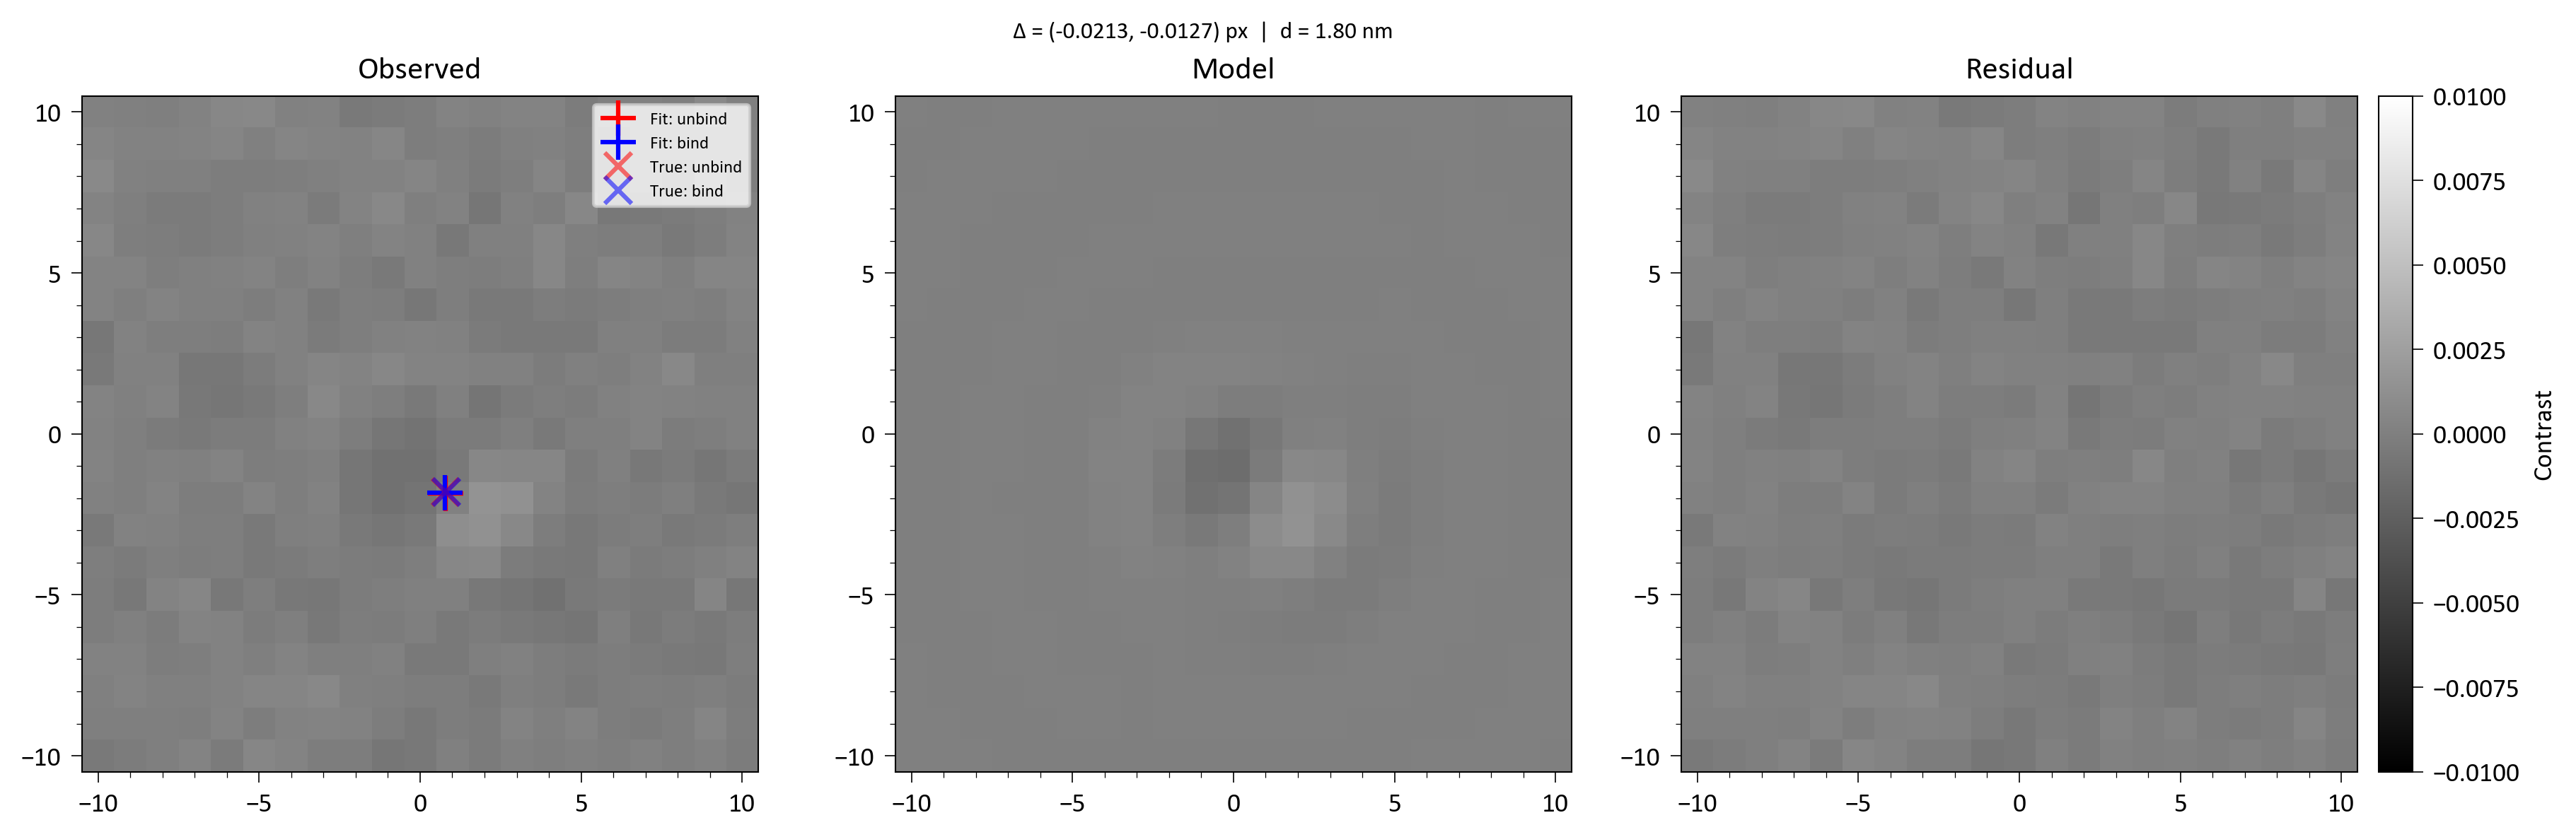

In [19]:
# True positions in PSF coordinates (pixel offsets from thumbnail centre)
TRUE_X_UNBIND, TRUE_Y_UNBIND = (X_OFFSET_PX, Y_OFFSET_PX)
TRUE_DISP_PX   = BUFFER_DISTANCE_NM / NM_PER_PIXEL   # movement along +x
x_moved, y_moved = r_theta_2_dx_dy(TRUE_DISP_PX, ANGLE_DEGREES)
TRUE_X_BIND    = TRUE_X_UNBIND + x_moved
TRUE_Y_BIND    = TRUE_Y_UNBIND + y_moved
TRUE_CONTRAST  = conversion_funcs["mass_to_c"](3_000)

### NEED A VERY GOOD GUESS ###
MIDPOINT_GUESS = (X_OFFSET_PX + np.random.uniform(-0.5, 0.5), Y_OFFSET_PX + np.random.uniform(-0.5, 0.5))
print(f"Midpoint guess: {MIDPOINT_GUESS}")


fit_flat = fit_movement(
    image=r_3000_buffer,
    midpoint=MIDPOINT_GUESS,
    contrast=TRUE_CONTRAST,
    method="Powell"
)

print(f"{'':12s}  {'x (px)':>10s}  {'y (px)':>10s}")
print(f"{'True unbind':12s}  {TRUE_X_UNBIND:10.4f}  {TRUE_Y_UNBIND:10.4f}")
print(f"{'Fit  unbind':12s}  {fit_flat.x_unbind:10.4f}  {fit_flat.y_unbind:10.4f}")
print(f"{'True bind':12s}  {TRUE_X_BIND:10.4f}  {TRUE_Y_BIND:10.4f}")
print(f"{'Fit  bind':12s}  {fit_flat.x_bind:10.4f}  {fit_flat.y_bind:10.4f}")
print(f"\nTrue displacement : {TRUE_DISP_PX:.4f} px  ({TRUE_DISP_PX*NM_PER_PIXEL:.1f} nm)")
fit_disp = np.hypot(fit_flat.x_bind  - fit_flat.x_unbind,
                    fit_flat.y_bind  - fit_flat.y_unbind)
print(f"Fit  displacement : {fit_disp:.4f} px  ({fit_disp * NM_PER_PIXEL:.1f} nm)")
print(f"Loss (sum sq res) : {fit_flat.fit_result.fun:.4e}")

plot_movement_fit(
    r_3000_buffer,
    fit_flat,
    vmin=-0.01, vmax=0.01,
    true_x_unbind=TRUE_X_UNBIND, true_y_unbind=TRUE_Y_UNBIND,
    true_x_bind=TRUE_X_BIND,     true_y_bind=TRUE_Y_BIND,
)

## 9. Fitting 2D Gaussian to Experimental PSF


In [93]:
from alex_area.movie_generator.sim_movie import CachedPSF

ePSF = CachedPSF(expPSF, l_thum=21)


def model(x, y, sigma):
    return -1.0 * np.exp(-((x) ** 2 + (y) ** 2) / (2 * sigma**2))

In [85]:
from scipy.optimize import curve_fit


def fit_psf_gaussian(
    image: np.ndarray,
    x0: float = 0.0,
    y0: float = 0.0,
) -> tuple[float, float]:
    """Fit an isotropic 2D Gaussian to a PSF image, centre fixed.

    Model: ``A · exp(-((x - x0)² + (y - y0)²) / (2σ²))``

    Amplitude A and sigma are both free; the centre (x0, y0) is held fixed.
    Coordinates are pixel offsets from the array centre.

    Parameters
    ----------
    image :
        2D PSF image, shape ``(N, N)``.
    x0, y0 :
        Fixed Gaussian centre in pixel offsets from the array centre
        (default ``0, 0`` — the thumbnail centre).

    Returns
    -------
    amplitude : float
    sigma_px : float
        Standard deviation in pixels.
    """
    ny, nx = image.shape
    lh = ny // 2
    yi, xi = np.indices(image.shape)
    xc = xi.astype(float) - lh
    yc = yi.astype(float) - lh

    def _model(coords, sigma):
        x, y = coords
        return -1.0 * np.exp(-((x - x0) ** 2 + (y - y0) ** 2) / (2 * sigma ** 2))

    popt, _ = curve_fit(
        _model,
        (xc.ravel(), yc.ravel()),
        image.ravel(),
        p0=[0.5],  # centre pixel value, ~2 px sigma
    )
    return float(popt[0])

In [86]:
signal = ePSF(x_off=0.0, y_off=0.0, c=1.0)

sigma_fit = fit_psf_gaussian(signal)
# print(f"Fitted amplitude : {amplitude_fit:.6f}")
print(f"Fitted sigma     : {sigma_fit:.4f} px  ({sigma_fit * NM_PER_PIXEL:.1f} nm)")

Fitted sigma     : 0.9665 px  (70.2 nm)


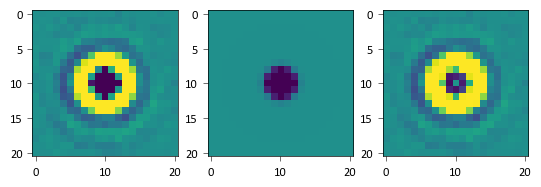

In [92]:
signal = ePSF(x_off=0.0, y_off=0.0, c=1.0)
xx, yy = CachedPSF._gen_offset_mgrid(0.0, 0.0, -10, 10, 21)

fit = model(xx, yy, 1.0)

fig, axs =plt.subplots(1,3)

axs[0].imshow(signal, vmin=-0.1, vmax=0.1)
axs[1].imshow(fit, vmin=-0.1, vmax=0.1)
axs[2].imshow(signal - fit, vmin=-0.1, vmax=0.1)